# SST Upwelling Binary Segmentation Video
Generates a daily binary segmentation video representing upwelling (SST $\le$ daily spatial mean - 1 $\sigma$) vs non-upwelling (SST > daily spatial mean - 1 $\sigma$).

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
import warnings

# Create directory for videos
os.makedirs('videos', exist_ok=True)

In [2]:
# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


In [3]:
# 2. Process 7-day sliding window grids for 2018
from datetime import timedelta

df_2018 = df.loc['2018'].copy()
unique_dates = sorted(list(set(df_2018.index.date)))

dates = []
grids = []
thresholds = []

print("Processing 7-day sliding window grids for 2018...")
for target_date in unique_dates:
    start_date = target_date - timedelta(days=6)
    
    # Get subset of dataframe for the 7-day window ending on target_date
    window_df = df_2018.loc[str(start_date):str(target_date)]
    
    window_grids = []
    for _, row in window_df.iterrows():
        grid = row.get('sst')
        if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
            window_grids.append(np.array(grid, dtype=float))
            
    if not window_grids:
        continue
        
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        sst_grid = np.nanmean(np.stack(window_grids), axis=0)
        
    # Calculate spatial mean and standard deviation for the window's averaged grid
    mean_sst = np.nanmean(sst_grid)
    std_sst = np.nanstd(sst_grid)
    threshold = mean_sst - std_sst
    
    seg_grid = np.zeros_like(sst_grid)
    target_mask = sst_grid <= threshold
    seg_grid[target_mask] = 1
    
    # Preserve NaNs
    seg_grid[np.isnan(sst_grid)] = np.nan
        
    dates.append(target_date)
    grids.append(seg_grid)
    thresholds.append(threshold)

Processing 7-day sliding window grids for 2018...


Generating video with 365 frames...


KeyboardInterrupt: 

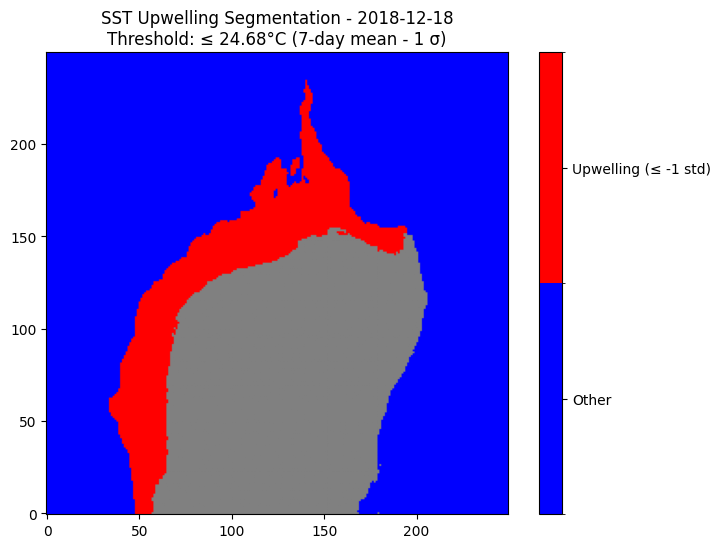

In [4]:
# 3. Create Video Animation
print(f"Generating video with {len(grids)} frames...")
fig, ax = plt.subplots(figsize=(8, 6))

# Binary map colors: Other=Blue, Target=Red
cmap = mcolors.ListedColormap(['blue', 'red'])
cmap.set_bad('grey') # Color for NaNs (land/missing)
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

cax = ax.imshow(grids[0] if grids else np.zeros((10,10)), cmap=cmap, norm=norm, origin='lower', animated=True)
cbar = fig.colorbar(cax, ax=ax, ticks=[0, 1])
cbar.ax.set_yticklabels(['Other', 'Upwelling (\u2264 -1 std)'])

title = ax.set_title('')

def update(frame_idx):
    cax.set_array(grids[frame_idx])
    title.set_text(f'SST Upwelling Segmentation - {dates[frame_idx]}\nThreshold: \u2264 {thresholds[frame_idx]:.2f}\u00b0C (7-day mean - 1 \u03c3)')
    return cax, title

if grids:
    ani = FuncAnimation(fig, update, frames=len(grids), blit=False)
    video_path = 'videos/sst_upwelling_2018_7day_window.mp4'
    
    try:
        ani.save(video_path, fps=10, writer='ffmpeg')
        print(f"Video successfully saved to {video_path}")
    except RuntimeError as e:
        print("Could not save mp4 via ffmpeg. Attempting fallback to save via pillow as a GIF...")
        gif_path = video_path.replace('.mp4', '.gif')
        ani.save(gif_path, fps=10, writer='pillow')
        print(f"Video saved as GIF instead at {gif_path}")
plt.close()

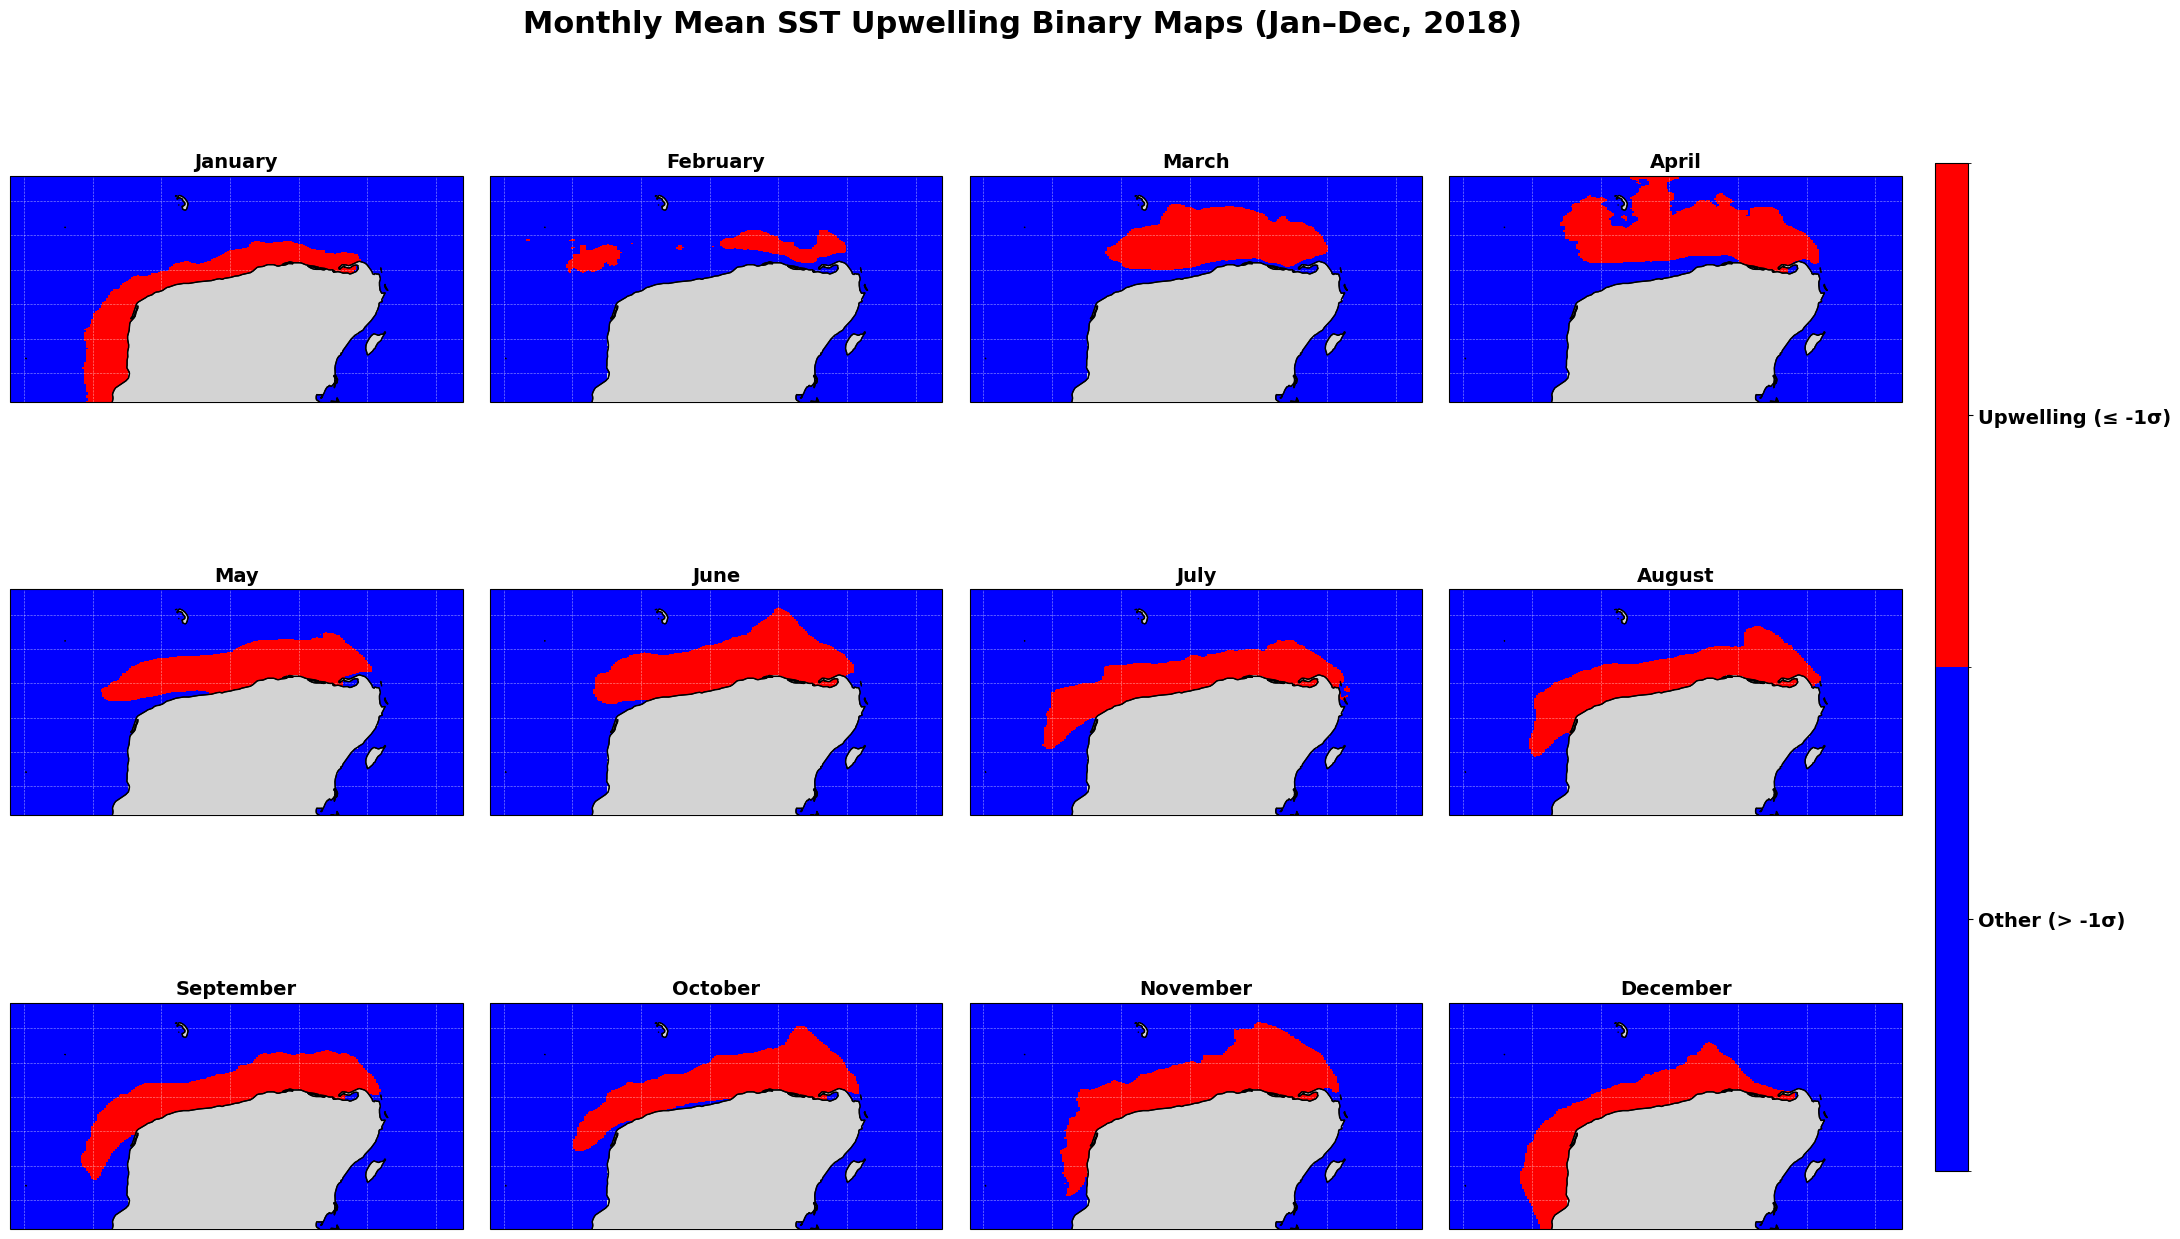

In [5]:
# Plot Monthly 3x4 Grid of Binary Upwelling Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Extract coordinates from metadata
lon_centers = np.array(data['metadata']['lon_centers'])
lat_centers = np.array(data['metadata']['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

months = range(1, 13)
month_names_full = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']

monthly_binary = {}

# Compute monthly means and their binary upwelling threshold 
for m in months:
    month_rows = df_2018[df_2018.index.month == m]
    month_grids = []
    for _, row in month_rows.iterrows():
        grid = row.get('sst')
        if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
            month_grids.append(np.array(grid, dtype=float))
            
    if month_grids:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            mean_month_sst = np.nanmean(np.stack(month_grids), axis=0)
            
        spatial_mean = np.nanmean(mean_month_sst)
        spatial_std = np.nanstd(mean_month_sst)
        threshold = spatial_mean - spatial_std
        
        binary_grid = np.zeros_like(mean_month_sst)
        binary_grid[mean_month_sst <= threshold] = 1
        binary_grid[np.isnan(mean_month_sst)] = np.nan
        monthly_binary[m] = binary_grid
    else:
        monthly_binary[m] = None

# Region extent
lat_min, lon_min = 19.57871, -92.20216
lat_max, lon_max = 22.86906, -85.61256

fig, axes = plt.subplots(3, 4, figsize=(22, 14), subplot_kw={'projection': ccrs.PlateCarree()})

cmap = mcolors.ListedColormap(['blue', 'red'])
cmap.set_bad('lightgray') # Color for NaNs (land/missing)
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

mesh_for_cbar = None

for month_num, ax in enumerate(axes.ravel(), start=1):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.45, color='white', alpha=0.55, linestyle='--', zorder=2)
    
    data_grid = monthly_binary.get(month_num)
    
    if data_grid is None:
        ax.set_title(f"{month_names_full[month_num-1]}\nNo Data", fontsize=14, fontweight='bold')
        continue
        
    mesh = ax.pcolormesh(
        lon_grid_2d, lat_grid_2d, data_grid,
        cmap=cmap, transform=ccrs.PlateCarree(),
        norm=norm, shading='auto', zorder=1
    )
    
    if mesh_for_cbar is None:
        mesh_for_cbar = mesh
        
    ax.set_title(f"{month_names_full[month_num-1]}", fontsize=14, fontweight='bold')

# Shared Colorbar
fig.subplots_adjust(left=0.04, right=0.90, bottom=0.05, top=0.90, wspace=0.06, hspace=0.14)
if mesh_for_cbar is not None:
    cax = fig.add_axes([0.915, 0.14, 0.015, 0.72])
    cbar = fig.colorbar(mesh_for_cbar, cax=cax, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Other (> -1\u03c3)', 'Upwelling (\u2264 -1\u03c3)'], fontsize=14, weight='bold')

fig.suptitle('Monthly Mean SST Upwelling Binary Maps (Jan–Dec, 2018)', fontsize=22, fontweight='bold', y=0.97)
plt.show()

Extracting daily CDOM pixels partitioned by Monthly Mean Upwelling masks...


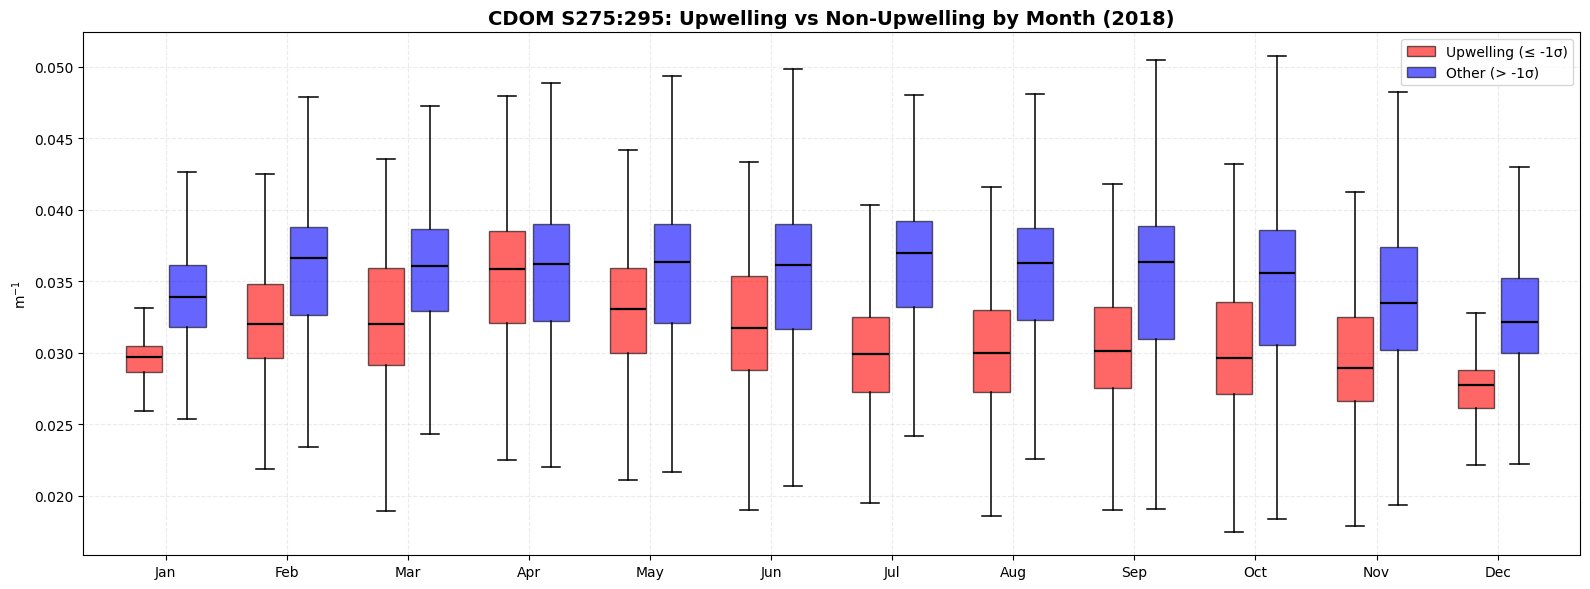

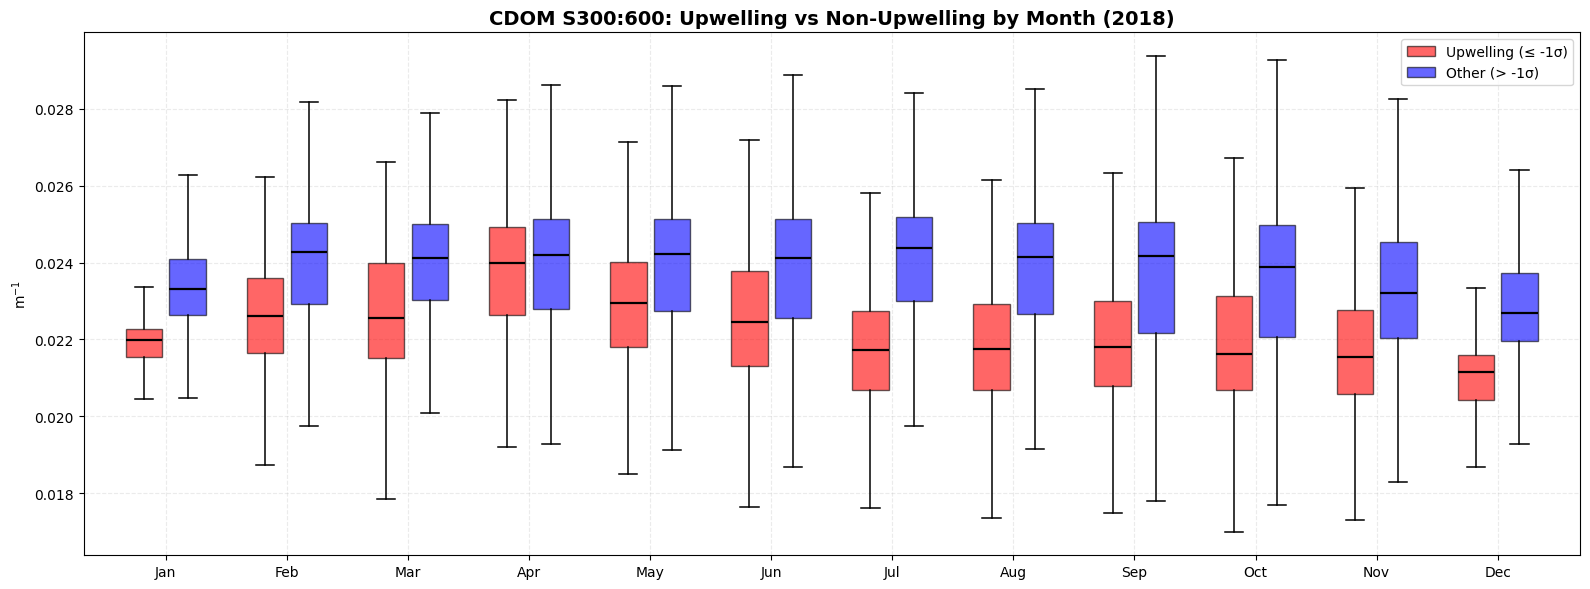

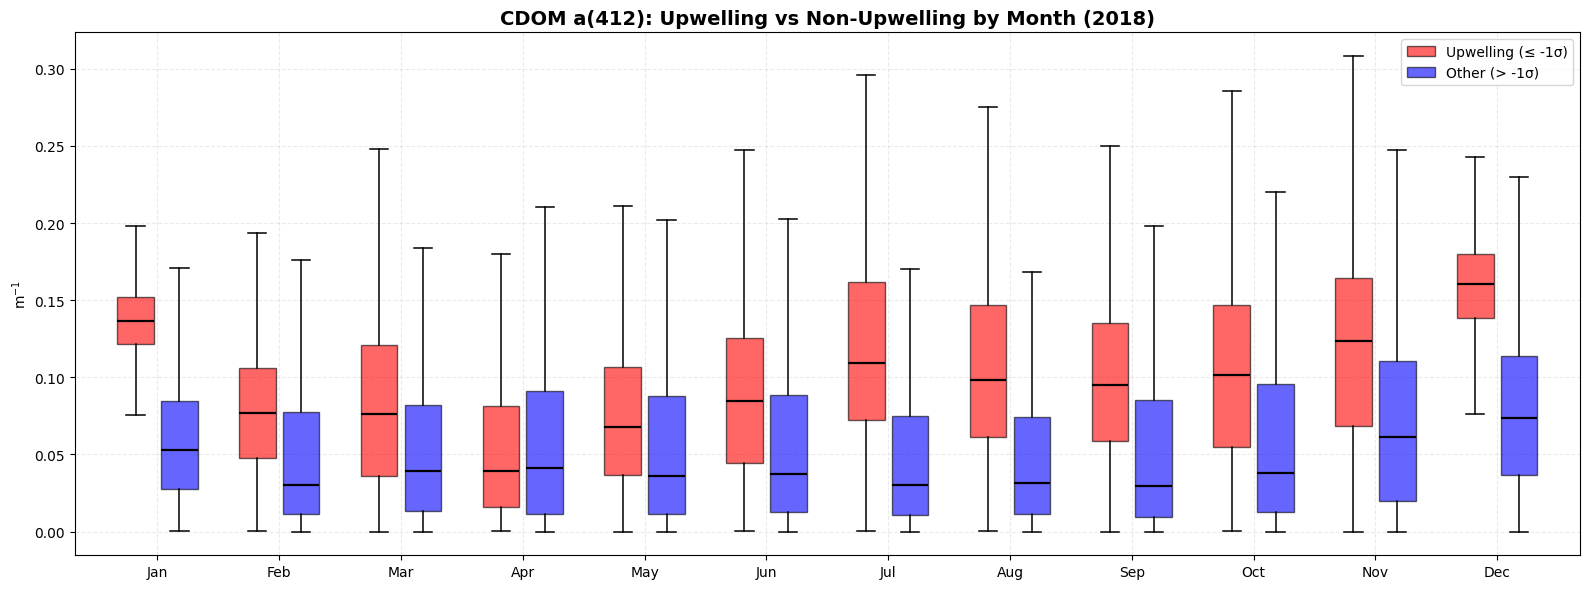

Generated 3 figures for monthly Upwelling vs Non-Upwelling CDOM comparisons.


In [6]:
# Create CDOM Upwelling vs Non-Upwelling Boxplots using Monthly Binary Maps 
from matplotlib.patches import Patch

all_month_labels = []
all_month_is_upwelling = []
all_month_s275 = []
all_month_s300 = []
all_month_a412 = []

def _is_missing_grid_local(grid_obj):
    return grid_obj is None or (isinstance(grid_obj, float) and np.isnan(grid_obj))

print("Extracting daily CDOM pixels partitioned by Monthly Mean Upwelling masks...")

for m in range(1, 13):
    bin_grid = monthly_binary.get(m)
    if bin_grid is None or isinstance(bin_grid, float):
        continue
        
    bin_flat = bin_grid.flatten()
    month_rows = df_2018[df_2018.index.month == m]
    
    for _, row in month_rows.iterrows():
        s275 = row.get('cdom_slope_275_295')
        s300 = row.get('cdom_slope_300_600')
        a412 = row.get('cdom_412', row.get('cdom'))
        
        if any(_is_missing_grid_local(g) for g in [s275, s300, a412]):
            continue
            
        s275_flat = np.array(s275, dtype=float).flatten()
        s300_flat = np.array(s300, dtype=float).flatten()
        a412_flat = np.array(a412, dtype=float).flatten()
        
        # Only keep valid pixels where all variables are finite
        valid_mask = (
            ~np.isnan(bin_flat) & 
            ~np.isnan(s275_flat) & 
            ~np.isnan(s300_flat) & 
            ~np.isnan(a412_flat) &
            (a412_flat > 0)
        )
        
        if not np.any(valid_mask):
            continue
            
        up_flags = bin_flat[valid_mask] == 1
        
        all_month_labels.extend([m] * int(np.sum(valid_mask)))
        all_month_is_upwelling.extend(up_flags)
        all_month_s275.extend(s275_flat[valid_mask])
        all_month_s300.extend(s300_flat[valid_mask])
        all_month_a412.extend(a412_flat[valid_mask])

all_month_labels = np.array(all_month_labels, dtype=int)
all_month_is_upwelling = np.array(all_month_is_upwelling, dtype=bool)
all_month_s275 = np.array(all_month_s275)
all_month_s300 = np.array(all_month_s300)
all_month_a412 = np.array(all_month_a412)

upwelling_mask = all_month_is_upwelling == True
non_upwelling_mask = all_month_is_upwelling == False

month_names_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def plot_monthly_upwelling_vs_nonupwelling(values, var_title, y_unit):
    fig, ax = plt.subplots(figsize=(16, 6))

    up_data = []
    non_data = []
    up_positions = []
    non_positions = []
    tick_positions = []

    for month in range(1, 13):
        month_mask = all_month_labels == month
        up_vals = values[month_mask & upwelling_mask]
        non_vals = values[month_mask & non_upwelling_mask]
        
        if up_vals.size == 0:
            up_vals = np.array([np.nan])
        if non_vals.size == 0:
            non_vals = np.array([np.nan])

        center = month
        up_positions.append(center - 0.18)
        non_positions.append(center + 0.18)
        tick_positions.append(center)

        up_data.append(up_vals)
        non_data.append(non_vals)

    bp_up = ax.boxplot(
        up_data,
        positions=up_positions,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.6},
        whiskerprops={'linewidth': 1.1},
        capprops={'linewidth': 1.1},
    )
    for patch in bp_up['boxes']:
        patch.set_facecolor('red')
        patch.set_alpha(0.60)
        patch.set_edgecolor('black')

    bp_non = ax.boxplot(
        non_data,
        positions=non_positions,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.6},
        whiskerprops={'linewidth': 1.1},
        capprops={'linewidth': 1.1},
    )
    for patch in bp_non['boxes']:
        patch.set_facecolor('blue')
        patch.set_alpha(0.60)
        patch.set_edgecolor('black')

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(month_names_short)
    ax.set_ylabel(y_unit)
    ax.set_title(f'{var_title}: Upwelling vs Non-Upwelling by Month (2018)',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.25, linestyle='--')

    legend_handles = [
        Patch(facecolor='red', edgecolor='black', alpha=0.60, label='Upwelling (\u2264 -1\u03c3)'),
        Patch(facecolor='blue', edgecolor='black', alpha=0.60, label='Other (> -1\u03c3)'),
    ]
    ax.legend(handles=legend_handles, loc='best')

    plt.tight_layout()
    plt.show()

if all_month_labels.size > 0:
    plot_monthly_upwelling_vs_nonupwelling(all_month_s275, 'CDOM S275:295', 'm$^{-1}$')
    plot_monthly_upwelling_vs_nonupwelling(all_month_s300, 'CDOM S300:600', 'm$^{-1}$')
    plot_monthly_upwelling_vs_nonupwelling(all_month_a412, 'CDOM a(412)', 'm$^{-1}$')
    print('Generated 3 figures for monthly Upwelling vs Non-Upwelling CDOM comparisons.')
else:
    print("No valid CDOM data found to plot.")

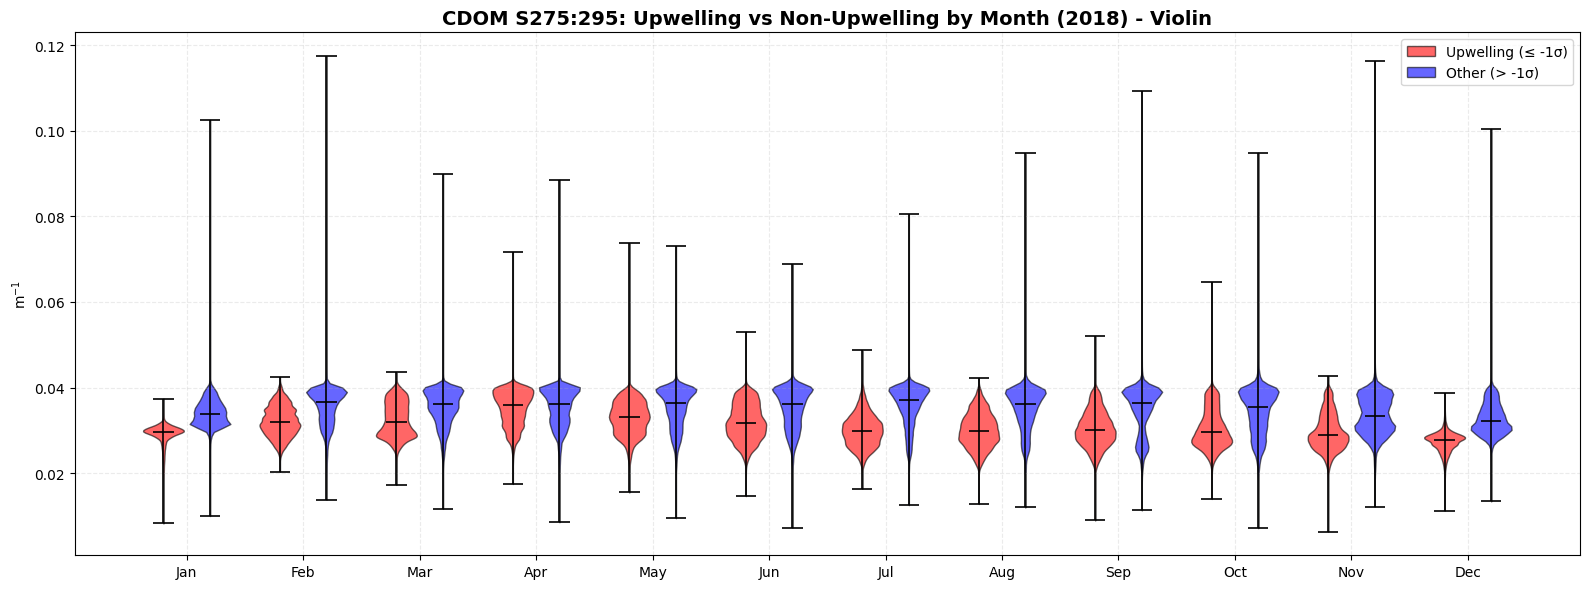

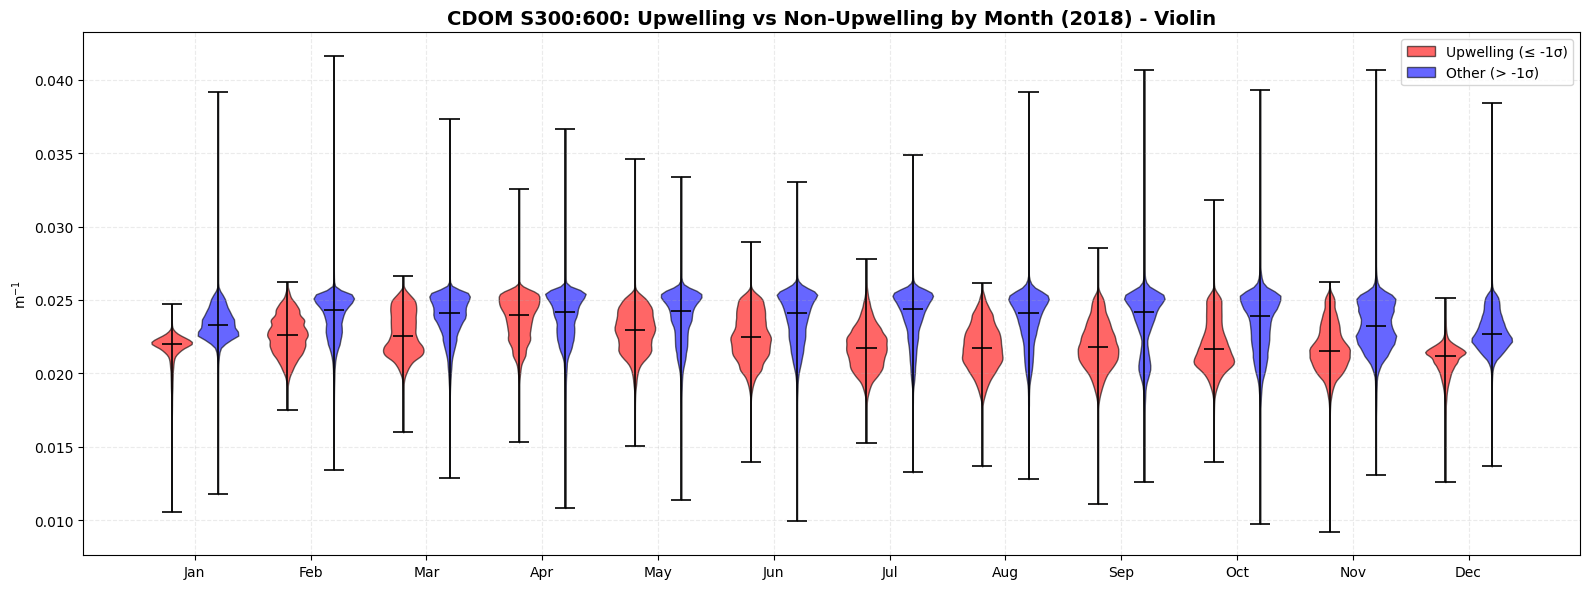

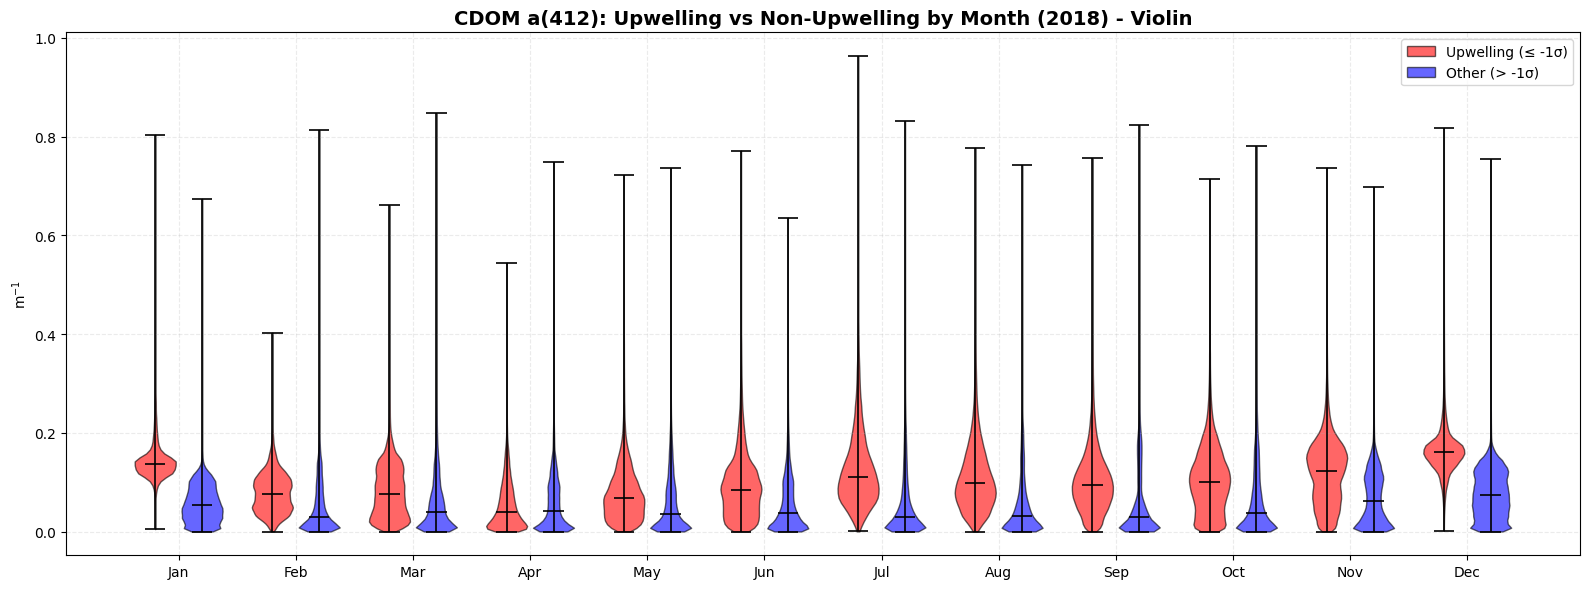

Generated 3 violin plots for monthly Upwelling vs Non-Upwelling CDOM comparisons.


In [7]:
# Create CDOM Upwelling vs Non-Upwelling Violin Plots using existing data
from matplotlib.patches import Patch
import numpy as np

def plot_monthly_upwelling_vs_nonupwelling_violin(values, var_title, y_unit):
    fig, ax = plt.subplots(figsize=(16, 6))

    up_data = []
    non_data = []
    up_positions = []
    non_positions = []
    tick_positions = []

    for month in range(1, 13):
        month_mask = all_month_labels == month
        up_vals = values[month_mask & upwelling_mask]
        non_vals = values[month_mask & non_upwelling_mask]
        
        # Remove NaNs if any
        up_vals = up_vals[~np.isnan(up_vals)]
        non_vals = non_vals[~np.isnan(non_vals)]

        center = month
        tick_positions.append(center)

        if up_vals.size > 0:
            up_data.append(up_vals)
            up_positions.append(center - 0.2)
            
        if non_vals.size > 0:
            non_data.append(non_vals)
            non_positions.append(center + 0.2)
            
    if up_data:
        vp_up = ax.violinplot(
            up_data,
            positions=up_positions,
            widths=0.35,
            showmeans=False,
            showmedians=True,
            showextrema=True
        )
        for pc in vp_up['bodies']:
            pc.set_facecolor('red')
            pc.set_edgecolor('black')
            pc.set_alpha(0.60)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp_up[partname].set_edgecolor('black')
            vp_up[partname].set_linewidth(1.2)

    if non_data:
        vp_non = ax.violinplot(
            non_data,
            positions=non_positions,
            widths=0.35,
            showmeans=False,
            showmedians=True,
            showextrema=True
        )
        for pc in vp_non['bodies']:
            pc.set_facecolor('blue')
            pc.set_edgecolor('black')
            pc.set_alpha(0.60)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp_non[partname].set_edgecolor('black')
            vp_non[partname].set_linewidth(1.2)

    ax.set_xticks(tick_positions)
    month_names_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ax.set_xticklabels(month_names_short)
    ax.set_ylabel(y_unit)
    ax.set_title(f'{var_title}: Upwelling vs Non-Upwelling by Month (2018) - Violin',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.25, linestyle='--')

    legend_handles = [
        Patch(facecolor='red', edgecolor='black', alpha=0.60, label='Upwelling (≤ -1σ)'),
        Patch(facecolor='blue', edgecolor='black', alpha=0.60, label='Other (> -1σ)'),
    ]
    ax.legend(handles=legend_handles, loc='best')

    plt.tight_layout()
    plt.show()

if all_month_labels.size > 0:
    plot_monthly_upwelling_vs_nonupwelling_violin(all_month_s275, 'CDOM S275:295', 'm$^{-1}$')
    plot_monthly_upwelling_vs_nonupwelling_violin(all_month_s300, 'CDOM S300:600', 'm$^{-1}$')
    plot_monthly_upwelling_vs_nonupwelling_violin(all_month_a412, 'CDOM a(412)', 'm$^{-1}$')
    print('Generated 3 violin plots for monthly Upwelling vs Non-Upwelling CDOM comparisons.')
else:
    print("No valid CDOM data found to plot.")

make graph start at 0
trim edges
cdom vs. chloro
